<h1> Linear Regression </h1>
This Notebook will outline the code I used to create a linear regression model from scratch. <br>This model supports a multivariate and univariate set of inputs and it outputs a single target value in every case. This Notebook doesn't go into general linear regression, but the ideas stay the same.<br><br>
The written explanations will be based on the <i> Advertising Sales </i> dataset, but the code itself is based on the <i> House Prices </i> dataset. This shows how easily the code can be modified for other datasets.
<br>

Let's get started, shall we?

## Table of Contents
1. [Prerequisites](#pre-req)
2. [Data Preprocessing](#pre-process)
3. [Linear Regression Model: Model Training & Prediction](#train)
4. [Graphical Analysis](#graph-visuals)
5. [Customization: Other Datasets](#dataset)

<div id = "pre-req"/><h2> Prerequisites </h2>
To ensure that my code runs properly, you would need to install 2 external libraries called <b> ScottPlot </b> which is used for plotting and <b>ImageMagick</b> for creating gifs and animations. Furthermore, you will also need to install <b>dotnet-interactive</b>, which provides the kernel that allows you to run C# code from this notebook. You can then select the kernel in the top-right menu. <br>
<br>
You can install the plotting library and the animations library in the below code cell. <br> See <a href = "https://devblogs.microsoft.com/dotnet/net-interactive-is-here-net-notebooks-preview-2/">Installation Instructions</a> for more information on how to configure the kernel. <br>Also, please view this notebook in the jupyter server (which you also need to install) for the best experience otherwise the latex may not render properly. <br>To view the notebook from the server, open the parent folder in the command prompt and type the command: <i>jupyter notebook</i><br>

In [1]:
// Installing External Packages (ScottPlot & ImageMagick).
#r "nuget: ScottPlot, 5.1.57"
#r "nuget: Magick.NET-Q16-AnyCPU, 14.10.2"

The below script needs to be able to find the current output cell; this is an easy method to get it.

Installed Packages Magick.NET-Q16-AnyCPU, 14.10.2 ScottPlot, 5.1.57

Loading extensions from `C:\Users\saksh\.nuget\packages\skiasharp\3.119.0\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`

To run the cells, hold the <b>Shift</b> key and then press <b>Enter</b>.<br>
To edit the cells, <b>double click</b> on them.</p>

<div id = "pre-process" /><h2> Part 1: Data Preprocessing (Data Loading) </h2>
<p> In this section, I will begin by loading data from a given dataset (in this case the <i> Advertising Sales </i> dataset found inside the <i> advertising </i> folder as <i>advertising.csv</i>). Ideally, this program is designed to work with .txt or .csv files where each line of the file represents a list of features representing the input along with an output target, all separated by a common separator (not necessarily a comma). The output target can be anywhere in each line, so long as it is in the same index location of each row.</p>
<p>For example in this dataset, each row represents (in order from left to right) the TV budget (in thousands), the Radio budget (in thousands), the Newspaper budget (in thousands) and the Sales Made (in thousands). Our goal with this dataset is to predict the sales likely to be made using a linear regression model when given the TV, Radio and Newspaper Budget. We need all of this information to be stored as a separate .txt file (header file) containing the header information required to allow you to make predictions with the model itself.</p>
<p> This is a lot to take in, so I can summarise these requirements by declaring constants that can be used throughout the notebook. </p>

In [2]:
// You Can Customise This to Fit Any Dataset You Like (see Section 4 for more dataset ideas).
const string TRAINING_DATA_PATH = @"Datasets\house prices\train.data"; 
const string HEADER_PATH = @"Datasets\house prices\date headers (tabs).txt"; 
const string SEPARATOR = "\t";
const int TARGET_LOCATION = 1; // Index Number from 0 to number of columns - 1 indicating which column contains the targets.

<h3>1.1 Transforming Data</h3>
<p>Next, we will create a function that will transform each feature / target of each line in the data into something usable for calculations. While this doesn't have to be done in this case (because the inputs are clearly in the format of decimal numbers: see <i>advertising.csv</i> under <i>advertising</i>), in general not all inputs are continuous values: if one of the inputs was a date, then we need to figure out a way to convert a date to a number which would make it a lot easier to do calculations.</p>
<p>Personally the way I do this is by creating two transformers: one of which transforms the <i>string feature values</i> and the other transforms the <i>target values</i> read-in from the file. I did this because it makes this code more reusable in Section 2.5, when we would need these transformers again to make predictions. Furthermore, it also makes them more flexible for you to implement (if you want to work with a custom dataset).</p>
<p>Because the dataset I am working on is simple, I just need to use C#'s built-in <i>double.Parse</i> function to convert a string to a double. If you wanted to use your own dataset, then you may need to modify this function to suit your needs.</p>

In [3]:
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        // You Can Add Code Here to Modify the Transformer to suit your dataset.
        string featureToTransform = featuresToTransform[i];
        string[] monthAndYear = featureToTransform.Split(" ");
        string month = monthAndYear[0]; int year = int.Parse(monthAndYear[1]);
        int monthNumber;
        switch (month)
        {
            case "Jan":
                monthNumber = 0; break;
            case "Feb":
                monthNumber = 1; break;
            case "Mar":
                monthNumber = 2; break;
            case "Apr":
                monthNumber = 3; break;
            case "May":
                monthNumber = 4; break;
            case "Jun":
                monthNumber = 5; break;
            case "June":
                monthNumber = 5; break;
            case "Jul":
                monthNumber = 6; break;
            case "July":
                monthNumber = 6; break;
            case "Aug":
                monthNumber = 7; break;
            case "Sep":
                monthNumber = 8; break;
            case "Oct":
                monthNumber = 9; break;
            case "Nov":
                monthNumber = 10; break;
            case "Dec":
                monthNumber = 11; break;
            default:
                throw new Exception("Invalid Month Name!");
        }
        // Multiplying Year By 12 and Adding On Month Number is Easiest Way to Create 1-1 correspondence between dates and numbers.
        transformedFeatures[i] = 12 * year + monthNumber;
    }
    return transformedFeatures;
}

In [4]:
double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    double transformedTarget = double.Parse(targetToTransform);
    return transformedTarget;
}

<h3>1.2 Reading-in the Dataset File</h3>
<p> This is where we use File Handling Techniques to read in each line of the Dataset File. At this stage, we create 2 data structures to store the features and targets: a 2D jagged array called <i>features</i>, which stores the input features and where each sub-array represents a row of inputs, along with a regular array called <i>targets</i>, which store the target values that correspond to each input feature sub-array in the <i>features</i> array.</p>
<p>Furthermore for later sections (e.g. <i>Section 2.5</i>), we will also store the Headers of each feature along with the Target Variable which should be stored in a separate directory.</p>
<p> We will also display the first 5 results in the next code block to show that the data is being loaded correctly and that each target corresponds correctly with the input features. Note that if you wanted to use your own dataset (which may not contain numbers), this is a good opportunity to test out your transformer here.</p>
<p> Note that we use arrays rather than lists for performance reasons (we take advantage of the fact that arrays have constant access time).</p>

In [5]:
// Reading-In the Input Features & Targets.
#nullable enable
using System.IO; // File Handling.
List<double[]> featuresList = new(); // Storing All the Input Features. 
List<double> targetsList = new(); // Storing All the Targets.

using (StreamReader file = new StreamReader(TRAINING_DATA_PATH)) // Object is Automatically Disposed After end of block is reached.
{
    while (true) 
    {
        string? line = file.ReadLine();
        if (line is not null) 
        {
            string[] splitLine = line.Split(SEPARATOR);
            List<string> features = new(); // Each Line has a List of Features (have to store them as a string list and then transform them).
            for (int i = 0; i < splitLine.Length; i++) 
            {
                string featureOrTargetValue = splitLine[i]; // Applies Transformer Function.
                if (i == TARGET_LOCATION) 
                    targetsList.Add(TargetTransformer(featureOrTargetValue)); // We found the Target (& transformed it): Have to Add it Separately.
                else 
                    features.Add(featureOrTargetValue); // We found one of the Input Features!
            }
            featuresList.Add(FeatureTransformer(features.ToArray())); // List-to-Array Conversion along with Feature Transformation.
        }
        else 
        {
            // We Have Reached End-of-File.
            break;
        }
    }
}
// More List-to-Array Conversions.
double[][] arrayOfFeatures = featuresList.ToArray();
double[] arrayOfTargets = targetsList.ToArray();
// Checking If Some Data Was Even Loaded.
if (arrayOfTargets.Length == 0)
{
    throw new Exception("Error! Please Provide Some Training Data First!");
}
Console.WriteLine("Data Loading Complete..."); // Helpful Message.

Data Loading Complete...


In [6]:
// Reading-in All the Headers.
#nullable enable // Disables Null Warnings + Permits Me to Work with Null Values.
using System.IO;

string[] featureHeaders; // Headers of All of the Features.
string targetHeader; // Headers of the Target Value.
using (StreamReader file = new StreamReader(HEADER_PATH))
{
    string[] headers = new string[arrayOfFeatures[0].Length + 1]; // Storing All the Headers Including The Target Header.
    string? headerLine = file.ReadLine(); // Headers Should Be Stored as a Single Line at the Top.
    if (headerLine is not null)
        headers = headerLine.Split(SEPARATOR); // Splits Each Individual Header.
    // Identifying which headers are the target and which are the features.
    List<string> featureHeadersList = []; // Exactly One Header is Not a Feature.
    for (int i = 0; i < headers.Length; i++)
    {
        if (i == TARGET_LOCATION)
            // Assumes Target Location of Feature in Dataset = Target location of Feature in File (which should be the case).
            targetHeader = headers[i].Trim(); // Remove Whitespace.
        else
            featureHeadersList.Add(headers[i].Trim()); // Remove Whitespace.
    }
    featureHeaders = featureHeadersList.ToArray();
}
Console.WriteLine("Header Loading Complete..."); // Helpful Message.

Header Loading Complete...


Note, that I have also created a helper utility function called <b>DisplayString</b> to allow me to display contents of arrays.<br>
Seriously speaking, this is helpful beyond just linear regression!

In [7]:
// Helper Function to Display Contents of Array (Please Run This).
string DisplayString<T>(T[] items) // Supports Generic Typing for Flexibility (albeit a little unnecessary here...)
{
    string display = "["; // Display String (Can Be Printed Out on Console).
    foreach (T item in items) 
    {
        display += item.ToString() + ", "; // Very Important to Convert Item Back to String for Formatting Purposes.
    }
    display = display[..^2] + "]"; // Removes Last Two Characters (',' and ' ') from string and adds on closed bracket.
    return display;
}

In [8]:
// Displays First Few Read-ins of Test File along with the Headers.
// (Optional but great for testing your transformer function).
Console.WriteLine($"Feature Headers - {DisplayString<string>(featureHeaders)}, Target Header - {targetHeader}");
const int NUM_OF_ROWS_TO_DISPLAY = 5; // Can Modify This to Show as Many Rows as Needed.
for (int row = 0; row < Math.Min(NUM_OF_ROWS_TO_DISPLAY, arrayOfTargets.Length); row++)
{
    // Note: If NUM_OF_ROWS_TO_DISPLAY > rows in file, the entire file is displayed.
    string currFeature = DisplayString<double>(arrayOfFeatures[row]);
    double currTarget = arrayOfTargets[row];
    // Displaying Each Line.
    Console.WriteLine($"Row - {row + 1}: Features - {currFeature}, Target - {currTarget}");
}

Feature Headers - [Month And Year], Target Header - Average UK House Price
Row - 1: Features - [24132], Target - 154000
Row - 2: Features - [24133], Target - 153000
Row - 3: Features - [24134], Target - 153000
Row - 4: Features - [24135], Target - 155000
Row - 5: Features - [24136], Target - 154000


<h3>1.3 Data Normalisation</h3>
Here, it is very important for us to normalise our data because:
<ul>
<li> Gradient Descent Algorithms Work Best on Normalized Data (faster convergence).</li>
<li> Ensures all of the Features Are Equally Important (& so no one feature dominates the rest).</li>
</ul>
<br>
There are different Normalization Algorithms that can be used. However, I prefer to use the <b>Min-Max</b> Normalization Method Because It is Relatively Easy to Implement: it just compresses all of the data to a common interval from 0 to 1. Other Methods include Mean and Z-Score Normalization, and they are more statistical (& complicated!) approaches to Normalization.
<br><br>
Given a Dataset With a Maximum Value of B and a Minimum Value of A, we can rescale an individual data value ($x_0$) to another data value ($x_1$) that lies in the interval [0, 1] using the formula:
$$x_1 = \frac{x_0 - A}{B - A}$$
<br>
Here, the values of A and B are computed by taking the maximum and minimum values of each feature that lies in the same category (e.g we compute A and B separately for TV budget, Radio Budget, Newspaper Budget and the Sales in the "Advertising Sales" Dataset). <br><br>
Notice how there is a singular <i>edge case</i>: when A = B. This means every feature in the dataset has exactly the same value. In that case, I would set $x_1$ = 0 because this means the feature doesn't add any extra information to the variances in the output target or other features: it may as well not exist. However (depending on who you ask), different people have different viewpoints on this matter.
<br><br>
Note that we need to record both the values of A and B when it comes to "un-normalizing" our output target, because the original data itself wasn't normalized and so our output prediction needs to be converted back into something understandable. 

In [9]:
// Finding Maximum and Minimum Features / Targets.
int NUMBER_OF_FEATURES = arrayOfFeatures[0].Length; // Computing Number of Features (for future reference).
int NUMBER_OF_ROWS = arrayOfTargets.Length; // Computing Number of Rows (for future reference).
// Treat the Above Two Variables As Constants, Even though I cannot actually make them constant (because arrays aren't fixed at runtime).
double[] maxFeatures = new double[NUMBER_OF_FEATURES];
double maxTarget; 
double[] minFeatures = new double[NUMBER_OF_FEATURES];
double minTarget;

// Calculating the Maximum And Minimum of Each Feature.
for (int featureIndex = 0; featureIndex < NUMBER_OF_FEATURES; featureIndex++) // Don't Include Targets in this loop.
{
    maxFeatures[featureIndex] = double.NegativeInfinity; // We assume maximum value is -infinity, so that this value updates when new maxima are found.
    minFeatures[featureIndex] = double.PositiveInfinity; // We assume minimum value is infinity, so that this value updates when new minima are found.
    double feature;
    for (int row = 0; row < NUMBER_OF_ROWS; row++)
    {
        feature = arrayOfFeatures[row][featureIndex];
        if (feature > maxFeatures[featureIndex])
            maxFeatures[featureIndex] = feature; // We found a new Maximum Feature.
        if (feature < minFeatures[featureIndex])
            minFeatures[featureIndex] = feature; // We found a new Minimum Feature.
    }
}

// Calculating the Maximum and Minimum of the Target.
maxTarget = double.NegativeInfinity;
minTarget = double.PositiveInfinity;
foreach (double target in arrayOfTargets)
{
    if (target > maxTarget)
        maxTarget = target;
    if (target < minTarget)
        minTarget = target;
}

// Displaying Maximum and Minimum Features Array.
Console.WriteLine($"Maximum Features: {DisplayString<double>(maxFeatures)}");
Console.WriteLine($"Minimum Features: {DisplayString<double>(minFeatures)}");
Console.WriteLine($"Maximum Target: {maxTarget}");
Console.WriteLine($"Minimum Target: {minTarget}");

Maximum Features: [24310]
Minimum Features: [24132]
Maximum Target: 272000
Minimum Target: 152000


Now, we can actually carry out the Normalization Once We Have to Minimum and Maximum Values of Each Feature and Target.

In [10]:
// Normalizing Our Data using Min-Max Formula.
double[][] normalizedFeatures = new double[NUMBER_OF_ROWS][];
double[] normalizedTargets = new double[NUMBER_OF_ROWS];
for (int row = 0; row < NUMBER_OF_ROWS; row++)
{
    double[] normalizedFeatureInput = new double[NUMBER_OF_FEATURES];
    // Firstly, We Normalize The Input Array of Features.
    for (int featureIndex = 0; featureIndex < NUMBER_OF_FEATURES; featureIndex++)
    {
        if (minFeatures[featureIndex] == maxFeatures[featureIndex]) 
            normalizedFeatureInput[featureIndex] = 0; // My Stance: The Feature is Irrelevant if there is no variance in data.
        else
            normalizedFeatureInput[featureIndex] = (arrayOfFeatures[row][featureIndex] - minFeatures[featureIndex]) / (maxFeatures[featureIndex] - minFeatures[featureIndex]); // My Formula.
    }
    normalizedFeatures[row] = normalizedFeatureInput;
    // Now, We Normalize The Target.
    normalizedTargets[row] = (arrayOfTargets[row] - minTarget)/(maxTarget - minTarget);
}

// Displaying first N results (you can change value of N).
const int NUM_OF_RESULTS_TO_DISPLAY = 5;
for (int row = 0; row < Math.Min(NUM_OF_RESULTS_TO_DISPLAY, arrayOfTargets.Length); row++)
{
    // Note: If NUM_OF_RESULTS_TO_DISPLAY > rows in file, the entire dataset is displayed.
    string currNormalFeature = DisplayString<double>(normalizedFeatures[row]);
    double currNormalTarget = normalizedTargets[row];
    // Displaying Each Line.
    Console.WriteLine($"Normalized Row - {row + 1}: Features - {currNormalFeature}, Target - {currNormalTarget}");
}

Normalized Row - 1: Features - [0], Target - 0.016666666666666666
Normalized Row - 2: Features - [0.0056179775280898875], Target - 0.008333333333333333
Normalized Row - 3: Features - [0.011235955056179775], Target - 0.008333333333333333
Normalized Row - 4: Features - [0.016853932584269662], Target - 0.025
Normalized Row - 5: Features - [0.02247191011235955], Target - 0.016666666666666666


This concludes our Data Preprocessing / Data Loading Section.

<div id = "train" /><h2>Part 2: The Linear Regression Model</h2>

A linear regression model $f$ can be defined as a function that takes in a list of features ($x_0, x_1, x_2, \dots, x_i$) and outputs a prediction ($\hat{y}$) like as follows: $$\hat{y} = f(x_0, x_1, x_2, \dots, x_i) = m_0 \cdot x_0 + m_1 \cdot x_1 + m_2 \cdot x_2 + \dots + m_i \cdot x_i + b$$
where each of $m_1, m_2, m_3, \dots, m_i$ and $b$ are the parameters (weights) that determine the output of the function. <br><br>In machine learning, parameters and weights can be used interchangably in most situations, but there is a slight distinction between the two here: all of the $m_i$ are actually the weights which multiply the input feature by a constant value, and so measure how "important" a feature is. Whereas, the $b$ term is known as the bias term, which is a constant offset of the data. All of the $b$ and $m_i$ are collectively known as "parameters", which can be individually modified to change the performance of the model.<br><br>
Our goal now is to find the values of all of these parameters that makes the value of the prediction ($\hat{y}$) as close to the actual target value ($y$) as possible!

<h3>2.1 Error / Loss Function</h3>
<p>First things first, we need to create a Loss Function to evaluate the performance of our model. One of the most widely used loss functions in statistics and machine learning is known as the Mean Squared Error Loss Function. There are a couple reasons for this, most of which only start to become relevant when we move on to later sections. However, one of the main reasons for this is that it is very sensitive to extreme values away from the data (outliers), so it can be more useful to highlight potential weaknesses in the performance of the model when it considers how the linear regression model tries to "adapt to tricky situations".</p>
<br>Mathematically, we can define the Mean Squared Error loss function as:
$$MSE = \frac{1}{2n} \cdot \sum_{k = 1}^{n}(\hat{y_n} - y_n)^2$$
where:
<ul>
<li>$n$ is the number of rows in the dataset (meaning the total number of given targets).</li>
<li>$\hat{y_n}$ represents the nth prediction. </li>
<li>$y_n$ represents the nth target.</li>
</ul>
<br> Note that we divided the MSE function by an extra 2 for reasons that will become relevant later on in this section.

In [11]:
double MeanSquaredError(double[] targets, double[] predictions)
{
    // Calculates Mean Squared Error (with extra division of 2) when given the targets and predictions.
    // Simple Application of the Mathematical Formula Below.
    int numOfTargets = targets.Length;
    double error = 0;
    for (int i = 0; i < numOfTargets; i++)
    {
        error += (predictions[i] - targets[i]) * (predictions[i] - targets[i]);
    }
    return error / (2 * numOfTargets);
}

// Testing Out the Mean Squared Error Function on Sample Data (can change the sample data if you want).
double[] testTargets = [1, 3, 2, 4, 5];
double[] testPredictions = [0, 3, 2, 10, 5];
Console.WriteLine($"Test MSE: {MeanSquaredError(testTargets, testPredictions)}"); // Expected Output: ((1 - 0)^2 + (10 - 4)^2) / 2(5) = 37/10 = 3.7

Test MSE: 3.7


<h3>2.2 Initialising the Weights & Defining Linear Function</h3>
<p>We initialise an array of parameters ($w_0, \dots, w_{n-1}$ and $b$) where $n$ is the number of input features. Because as of now we do not know which weights allow us to obtain the closest predictions to the targets, we initialise each parameter to 0 for simplicity.</p>
<p>Furthermore, we define a linear function ($f$) that takes in the weights array as a parameter as well as the <b>normalized</b> input features. We can then compute the <b>normalized</b> prediction using the linear formula described at the beginning of the section. Note that I placed a heavy emphasis on the fact that the linear function is designed to only work with <b>normalized</b> inputs: to make a prediction based on the original data, I will need to first normalize the input features in the same way as before and then "un-normalize" the output prediction to a sensible value.</p> <p>Also beware that if a transformation has been applied on some of the input features, then the input features also need to be transformed using the same transformer and the output target may need to be "un-transformed" back into an easy-to-interpret value (e.g. back to a date). I will not do this "un-transformation" because all the datasets I use represent the target as a number, but I will create a template for you to create an inverse function of your transformer if need be. See <i>Section 2.5</i> (Prediction / Inference) to create these functions.</p>

In [12]:
// Defining Linear Function and Weights.
double[] parameters = new double[NUMBER_OF_FEATURES + 1]; // One Weight is Associated with Each Feature & Then Includes Bias Term.
// Note: Each value of the parameter is automatically assigned to 0 above because it is the default value of a double. This is nice!
double LinearFunction(double[] features, double[] parameters)
{
    // Linear Function that takes in NORMALIZED features & parameters and outputs NORMALIZED prediction.
    double prediction = 0;
    for (int i = 0; i < features.Length; i++)
    {
        // Multiply Each Feature By Corresponding Weight.
        prediction += features[i] * parameters[i];
    }
    prediction += parameters[^1]; // Adds On Bias Term (Last Term)!
    return prediction;
}
// Testing if Linear Function Works On Sample Set of Normalized Data.
double[] testFeatures = [0.5, 0.7, 0.2, 0.3];
double[] testParams = [1, 1, 0.2, 0.5, 0.7];
// Expected Output = 0.5 * 1 + 0.7 * 1 + 0.2 * 0.2 + 0.3 * 0.5 + 0.7 = 2.09
Console.WriteLine($"Test Prediction: {LinearFunction(testFeatures, testParams)}");

Test Prediction: 2.09


<h3>2.3 Gradient Descent Parameters (1st Stage of Learning)</h3>
<p>Now we have arrived at the main part of the model: how does the model <i>learn</i>? We achieve this through the main algorithm that allows us to update our parameters accordingly known as <b>Gradient Descent</b>.</p>
<p>Here, we declare some constants to be used to train the model, allowing us to tune the following features:</p>
<ul>
    <li>Learning Rate ($\alpha$)</li>
    <li>Number of Learning Iterations (epochs)</li>
</ul>
<p>You can experiment yourself (& move on to the Analysis Section) to Observe What Happens when the Learning Rate and the Number of Iteratons Changes. You may see that it is very important that the right learning rate is chosen: if it is too small, then the model's parameters will converge far too slowly to be useful and if it is too big, then the models parameters may diverge because the model may "overshoot" the lowest point of the error function.</p>
<p>Note that a problem with this approach is the gradient descent algorithm may only find the local minimum (not the global minimum), which is one of the main causes of neural networks not improving even after trying out many iterations. However, our choice of error function deliberately avoids this problem because the error function has got <i>exactly one local minimum</i>!</p>

In [13]:
const double LEARNING_RATE = 0.5; // Experimentally I Found 0.5 to Be Quite a Decent Value on Normalized Data! What do you think?
const int EPOCHS = 20000; // 20,000 epochs is a good starting point to balance performance with model accuracy.

<h3>2.4 Gradient Descent Algorithm (2nd Stage of Learning)</h3>
<p>Now we define the gradient descent algorithm that takes in the parameters and updates them according to the following formula:</p>
$$new(w_i) = w_i - \alpha \cdot \frac{∂}{∂w_i} MSE$$
$$new(b) = b - \alpha \cdot \frac{∂}{∂b} MSE$$
<p>We essentially find the slope of the gradient function at the point determined by the old parameters <b>with respect to the parameter being updated</b> only and ignoring the influence of other parameters at the point (to identify which direction to "slide" down the error function towards a local minimum value of error) and then multiply by the learning rate to determine how far should we slide down the error function in that direction.</p>
<p>For the formula to work, we must ensure that all the weights are updated <b>simultaneously</b> to again avoid the influence of other parameters on determining which direction should the parameter slide down. This means we have to create new variables that store all of the updated parameters, and then reassign all the parameters back to the array afterwards.</p>
<p>Next, we can use chain rule differentiation techniques (& by ignoring the constants), we can find exact expressions for the partial derivative of the gradient function.</p>
$$\frac{∂}{∂w_i} MSE = \frac{1}{n} \cdot \sum_{k=1}^{n} [x_i \cdot (\hat{y} - y)]$$ 
$$\frac{∂}{∂b} MSE = \frac{1}{n} \cdot \sum_{k=1}^{n} (\hat{y} - y)$$
where $w_i$ is multiplied with feature $x_i$.
<br><br>
<p>So, we can combine all of this information to now assemble the gradient descent algorithm. Note that the way I store parameters is by first <b>storing the weights in order</b> inside the array and then store the <b>bias term at the end of the array</b>.</p>

In [14]:
// Partial Derivative Function of MSE.
double[] Derivative(double[][] features, double[] targets, double[] parameters)
{
    // Calculates Gradient of Loss Function with Respect to All of the Parameters Provided.
    double[] derivatives = new double[parameters.Length];
    for (int paramIndex = 0; paramIndex < parameters.Length; paramIndex++) 
    {
        // Excluding Partial Derivative of Error Function with Respect to Each Weight & Bias Term.
        double ans = 0;
        for (int row = 0; row < targets.Length; row++)
        {
            double[] featureInput = features[row]; // Input List of Features.
            double target = targets[row]; // The Target Value.
            double prediction = LinearFunction(featureInput, parameters); // Calculates Prediction.
            if (paramIndex == parameters.Length - 1)
                // We Calculate Partial Derivative with Respect to Bias Term: No Need to Add Additional Multiplier.
                ans += prediction - target;
            else
                // We Calculate Partial Derivative with Respect to Weight: We Need to Add an Additional Multiplier.
                ans += featureInput[paramIndex] * (prediction - target);
        }
        ans /= targets.Length; // Don't Forget to Divide by n.
        derivatives[paramIndex] = ans; // Stores the Values of Derivatives in Array of Derivatives.
    }
    return derivatives;
}

In [15]:
using System.Diagnostics; // Measuring Time Taken for Model to Learn (useful for you to see if you are using too many or too little epochs...)

// Gradient Descent Algorithm (& also displays how well model is doing every so often).
double[] Learn(double[][] features, double[] targets, double[] parameters, double learningRate, int epochs)
{
    // We Return the Parameters Calculated By the Model after Gradient Descent.
    for (int epoch = 1; epoch <= epochs; epoch++)
    {
        // Start of Epoch.
        double[] slopes = Derivative(features, targets, parameters); // Calculating New Weights.
        for (int paramIndex = 0; paramIndex < parameters.Length; paramIndex++)
        {
            // Simultaneous Update of Parameter (Because we are updating AFTER calculating the derivative).
            parameters[paramIndex] -= learningRate * slopes[paramIndex];
        }
    }
    return parameters;
}

// Displaying the Calculated Model Parameters.
Stopwatch s = new();
s.Start();
parameters = Learn(normalizedFeatures, normalizedTargets, parameters, LEARNING_RATE, EPOCHS);
s.Stop();
Console.WriteLine($"Model Parameters: {DisplayString<double>(parameters)}");
Console.WriteLine($"Learning Time: {s.ElapsedMilliseconds} ms.");

Model Parameters: [1.1002513966480423, -0.07214618249534328]
Learning Time: 44 ms.


<p>What is also useful is if we could see how the error of the model changes as the weights are getting updated. To do this, we re-train the model over separate episodes (containing an equal number of epochs each) that you can change and adjust to satisfy your curiosity.</p>

In [16]:
const int NUM_EPISODES = 30; // Number of Training Episodes (originally was 100).
const int NUM_EPOCHS_PER_EPISODE = 20; // Number of Training Epochs per Episode (originally was 20).
double[] displayParameters = new double[parameters.Length]; // Creating an array of parameters to be updated for display purposes & MSE only.
for (int episode = 1; episode <= NUM_EPISODES; episode++)
{
    // We Update Parameters In Episodal Batches.
    displayParameters = Learn(normalizedFeatures, normalizedTargets, displayParameters, LEARNING_RATE, NUM_EPOCHS_PER_EPISODE);
    // Now, we Calculate Mean Squared Error With New Parameters.
    double[] normalizedPredictions = new double[normalizedTargets.Length]; // Stores All of the Normalized Predictions to Calculate Error With.
    for (int row = 0; row < normalizedTargets.Length; row++)
    {
        normalizedPredictions[row] = LinearFunction(normalizedFeatures[row], displayParameters); // Calculating Predictions.
    }
    double error = MeanSquaredError(normalizedTargets, normalizedPredictions); // Calculating Mean Squared Error Error
    // Displaying All the Relevant Results.
    Console.WriteLine($"Episode {episode}/{NUM_EPISODES}: MSE - {error}; Parameters - {DisplayString<double>(displayParameters)}");
}

Episode 1/30: MSE - 0.009938023513702033; Parameters - [0.6500873278647313, 0.16896212325427212]
Episode 2/30: MSE - 0.0035134619067590453; Parameters - [0.8712738607230704, 0.05049440521819734]
Episode 3/30: MSE - 0.001851245369132167; Parameters - [0.9837811680336737, -0.009764616414219081]
Episode 4/30: MSE - 0.0014211827458748272; Parameters - [1.0410084054144915, -0.0404155796069817]
Episode 5/30: MSE - 0.001309913331971004; Parameters - [1.0701172408894992, -0.056006299787853375]
Episode 6/30: MSE - 0.0012811247746750314; Parameters - [1.0849235523854144, -0.06393657441673123]
Episode 7/30: MSE - 0.0012736763573417654; Parameters - [1.0924548347791152, -0.06797033648543815]
Episode 8/30: MSE - 0.0012717492402514541; Parameters - [1.0962856480447503, -0.07002212374229921]
Episode 9/30: MSE - 0.0012712506403323568; Parameters - [1.0982342046794658, -0.07106577254352013]
Episode 10/30: MSE - 0.0012711216383736407; Parameters - [1.099225344861827, -0.07159662817518841]
Episode 11/30:

<p>If you ran the above code and the MSE decreases until it appears to converge to a constant value, then well done! <br>The model has successfully learnt as best as it could from the data & you chose a good learning rate.</p>

<h3>2.5 Prediction / Inference</h3>
<p>We're almost there! All we need to do now is to create a function that actually gives a prediction of the target when given the normalized features. Just as emphasised in <i>Section 2.2</i>, this would involve a lot of un-normalizing and even un-transforming the target value, to make the input features and the prediction easier to understand. After this, we can create a little interface that allows you to pass in certain features with a meaningful label (e.g. in the context of the <i>Advertising Sales</i> dataset, you should be able to enter the <i>TV budget</i>, <i>Radio Budget</i> and <i>Newspaper Budget</i> to predict the <i>Sales Made</i> as a result of the budget. Don't worry if the prediction given seems ridiculous: in real life, most relationships are non-linear and the model absolutely <b>cannot model non-linear relationships</b> by design. This is where neural networks step-in to make the model even more accurate (although they are more complex to implement).</p>

<p>Firstly, we can define our un-normalizer (inverse normalizer) function by rearranging the normalization equation I used earlier: $$x_1 = \frac{x_0 - A}{B - A} \implies x_0 = x_1 \cdot (B - A) + A$$</p>
<p>This demonstrates another advantage of my normalization method is that it is also easier to be inverted to retrieve the un-normalized values back again.</p>

In [17]:
// Inverse Normalization Function to Un-Normalize the Target.
double InverseNormal(double normalizedTarget, double maxTarget, double minTarget)
{
    return normalizedTarget * (maxTarget - minTarget) + minTarget; // Simple Application of Formula Above.
}

<p>Also, we need to create our normalization function that allows us to normalize all the input features using the same corresponding maxima and minima as earlier.</p>

In [18]:
// Normalization Function that Normalizes Input Features.
double[] NormalizeFeature(double[] feature, double[] maxFeatures, double[] minFeatures)
{
    // We Use Same Normalization Formula As Earlier.
    double[] normalized = new double[feature.Length]; // Array of Normalized Features.
    for (int i = 0; i < feature.Length; i++)
    {
        normalized[i] = (feature[i] - minFeatures[i]) / (maxFeatures[i] - minFeatures[i]); // Same Normalization Formula.
    }
    return normalized;
}

<p>Furthermore (like Mentioned in <i>Section 2.2</i>), you may also need to create an Inverse Transformer function that transforms the prediction from a double back into a value that is easier to interpret (e.g. a string date). In the case of my <i>Advertising Sales</i> dataset, I don't need to do anything more than converting my target value back to a string this because my target values are anyway numbers in the original file.</p>

In [19]:
// Inverse Transformer Template.
string InverseTransform(double transformedTarget)
{
    return transformedTarget.ToString();
}

Finally once we have both of these helper functions along with code from previous sections, we can now make a prediction using the same <i>LinearFunction</i> defined earlier.<br> Note that it takes in a string array because that represents the data-type of the user's input.

In [20]:
// Prediction Function.
string Predict(string[] features, double[] parameters)
{
    // Firstly, We Transform the Features into double array using same Transformer function as defined in Section 1.1
    double[] transformedFeatures = FeatureTransformer(features); // No Issues With Ordering!
    
    // Next, We Have to Normalize the Feature Input using the Same Corresponding Minimum and Maximum Features we had earlier.
    // Note maxFeatures & minFeatures are defined in Section 1.3 for this reason.
    double[] normalizedFeatures = NormalizeFeature(transformedFeatures, maxFeatures, minFeatures);
    
    // Then, we make a normalized & transformed prediction on these normalized Features.
    double normalizedAndTransformedPrediction = LinearFunction(normalizedFeatures, parameters);

    // Now We Have to Un-Normalize It and Un-Transform it to Get the Prediction.
    string prediction = InverseTransform(InverseNormal(normalizedAndTransformedPrediction, maxTarget, minTarget));
    return prediction;
}

<p>Now we can create our custom interface, allowing you to enter in a bunch of feature inputs and the model can give a prediction.</p>

In [21]:
// Interface to Allow You to Predict With Stuff!
#nullable enable // Annotation to Permit Usage of null.
using System.IO; // For Reading-in the Headers from the File.
using Microsoft.DotNet.Interactive; // For Reading-in the Inputs from the Notebook.
// Headers Have Been Retrieved Already from Section 1.2.

// Rest of Interface.
string[] featureInputs = new string[NUMBER_OF_FEATURES]; // NUMBER_OF_FEATURES is Defined in Section 1.3
for (int i = 0; i < NUMBER_OF_FEATURES; i++)
{
    // We are Going Under The Assumption that Number of Headers = Number of Features + 1.
    // If this is not true, then please fix the header file because that is supposed to be the case (or else a runtime error may be thrown).
    string? feature = await Microsoft.DotNet.Interactive.Kernel.GetInputAsync($"Enter {featureHeaders[i]}: "); // Console.ReadLine() doesn't work for some reason...
    while (feature is null)
    {
        // Basic Input Validation to Handle Null Inputs.
        Console.WriteLine("Invalid Input Enter Again: ");
        feature = await Microsoft.DotNet.Interactive.Kernel.GetInputAsync("Invalid Input Enter Again: ");
    }
    featureInputs[i] = (string)feature; // Recording the Feature.
}
// Displaying Prediction.
Console.WriteLine();
try
{
    string prediction = Predict(featureInputs, parameters); // Uses Same Parameters Array as Defined in Section 2.2
    Console.WriteLine($"Predicted {targetHeader}: {prediction}");
}
catch (Exception ex)
{
    Console.WriteLine($"Error Message: {ex.Message}");
    Console.WriteLine("Check Your Training Data: Did You Enter All the Inputs in the Correct Format?");
}


Predicted Average UK House Price: 490477.9549306378


<div id = "graph-visuals" /><h2>Part 3: Graphical Analysis</h2>
<p>This section will show some graphs using our installed plotting library <b>ScottPlot</b> that aim to measure the performance of the model. Furthermore, you may also be able to see a graph of the line of best fit as well as heatmaps but this is restricted to univariate linear regression only (as ScottPlot doesn't natively support plotting in higher dimensions). However, I will provide some 2D Datsets (e.g. the <i>House Price Prediction</i> dataset) that will show graphs of this nature.</p>
<p>Note that for the Graph to show, you also need to run the following code cell which is a utility function that allows Bitmap objects (created from <i>plt.GetImage</i> method) to render on screen as graphs.</p>

In [22]:
// Utility Function that Renders Image Object.
using Microsoft.DotNet.Interactive.Formatting;

const int IMAGE_WIDTH = 1000; // Originally 500
const int IMAGE_HEIGHT = 500; // Originally 500.
// Code Source: https://scottplot.net/quickstart/notebook/
Formatter.Register(typeof(ScottPlot.Plot), (p, w) => 
    w.Write(((ScottPlot.Plot)p).GetPngHtml(IMAGE_WIDTH, IMAGE_HEIGHT)), HtmlFormatter.MimeType);

<h3>3.1 Loss Function Graph (Multivariate & Univariate Datasets)</h3>
<p>This is essentially very similar to section 2.4 except I will provide a more visual diagram, showing how the MSE changes as the model learns over more and more iterations. Assuming that the model converges, we should see a graph that looks oddly similar to $y=\frac{1}{x}$ because at some point no matter how well-trained the model is, you cannot fit a better line of best fit on the data than you already have.</p>

Training Model...
Training Complete!



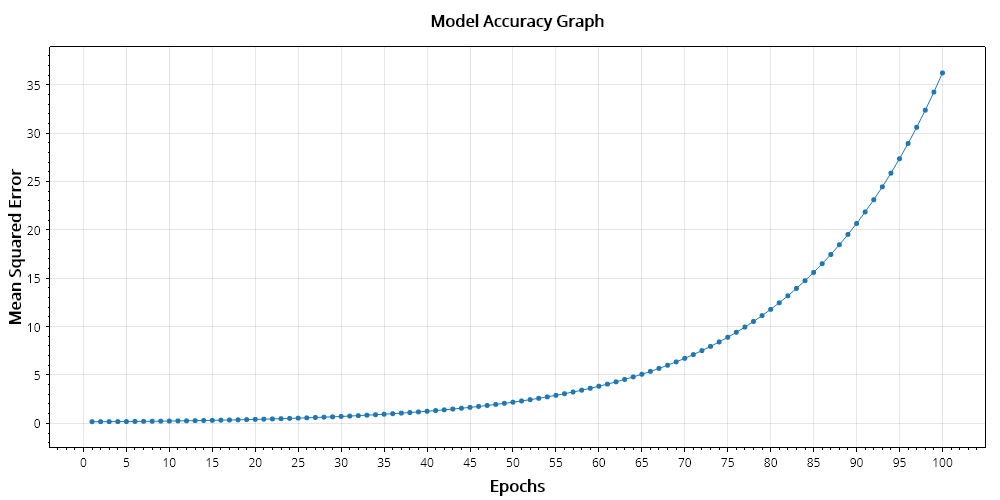

In [ ]:
// Loss Function Graph.
using ScottPlot; // Note that You Must Run the Very First Code Cell to ensure the library is installed on your machine.
const double LEARNING_RATE = 1.6; // Demonstrating divergent behaviour.
const int GRAPH_EPOCHS = 100; // You Can Change Maximum Number of Epochs. Originally, it was 50 for best results of graph.

// Creating & Populating Plotting Data.
Console.WriteLine("Training Model...");
double[] epochs = new double[GRAPH_EPOCHS];
double[] errors = new double[GRAPH_EPOCHS];
double[] graphParameters = new double[parameters.Length]; // Creating Separate Array of Parameters for Graphing Purposes Only.
for (int epoch = 1; epoch <= GRAPH_EPOCHS; epoch++)
{
    // We Update Parameters By Learning Exactly One Epoch.
    graphParameters = Learn(normalizedFeatures, normalizedTargets, graphParameters, LEARNING_RATE, 1);
    
    // Now, we Calculate Mean Squared Error With New Parameters.
    double[] normalizedPredictions = new double[normalizedTargets.Length]; // Stores All of the Normalized Predictions to Calculate Error With.
    for (int row = 0; row < normalizedTargets.Length; row++)
    {
        normalizedPredictions[row] = LinearFunction(normalizedFeatures[row], graphParameters); // Calculating Predictions.
    }

    double MSE = MeanSquaredError(normalizedTargets, normalizedPredictions); // Calculating Mean Squared Error.

    // Adding Plotting Data (Change from Previous Section), remembering that array indices start from 0.
    epochs[epoch - 1] = epoch;
    errors[epoch - 1] = MSE;
}
Console.WriteLine("Training Complete!");
// Plotting the Graph:
var plt = new ScottPlot.Plot();
plt.Add.Scatter(epochs, errors); // Plots Epochs on x-axis and MSE values on y-axis.
plt.XLabel("Epochs");
plt.YLabel("Mean Squared Error");
plt.Title("Model Accuracy Graph");
plt // Displays The Plot (The Utility Function Is Responsible for Rendering Graphs On Screen).

<h3>3.2 Line of Best Fit (Univariate Linear Regression Only)</h3>
<p>We will show two graphs in this section.</p>
<ol>
    <li>Line of Best Fit After Learning for a Specified Number of Epochs.</li>
    <li>Gif Showing How the Line of Best Fit Changes as Model Learns Over More Epochs.</li>
</ol>
<p>To show graphs for both of these, I will create another utility function that returns the plots generated after drawing a line of best fit on the data.</p>
<p>Note that in order for this to work, I will have to plot a graph of the <b>transformed</b> feature and the <b>transformed</b> target, using the <i>Transformer</i> function defined earlier. This is mainly because ScottPlot only supports plotting double values (just like most other plotting software even in other programming languages). However, you can choose to plot the normalized version of this transformed data or just the un-normalized version if you'd like.</p>

In [24]:
// Utility Function(s) to Re-format All the Targets and Features for Plotting Suitablility & Plots a Scatter Graph.
double[] ReformatFeatures(bool normalize = false)
{
    // Note That It Makes External Access to Other Variables Created in Other Code Cells.
    double[] univariateFeatures = new double[NUMBER_OF_ROWS];
    for (int row = 0; row < NUMBER_OF_ROWS; row++)
    {
        univariateFeatures[row] = arrayOfFeatures[row][0]; // Using arrayOfFeatures Obtained From Section 1.2
        if (normalize)
        {
            // Using Normalized Versions of Features and Targets Obtained From Section 1.3
            univariateFeatures[row] = normalizedFeatures[row][0];
        }
    }
    return univariateFeatures;
}

double[] ReformatTargets(bool normalize = false)
{
    // Note That It Makes External Access to Other Variables Created in Other Code Cells.
    double[] univariateTargets = new double[NUMBER_OF_ROWS];
    for (int row = 0; row < NUMBER_OF_ROWS; row++)
    {
        univariateTargets[row] = arrayOfTargets[row]; // Using arrayOfTargets Obtained From Section 1.2
        if (normalize)
        {
            // Using Normalized Versions of Features and Targets Obtained From Section 1.3
            univariateTargets[row] = normalizedTargets[row];
        }
    }
    return univariateTargets;
}

ScottPlot.Plottables.Scatter GetBaseScatterGraph(ScottPlot.Plot plt, double[] univariateFeatures, double[] univariateTargets, bool normalizedVersion = false)
{
    // Returns a Scatter Plot Containing the Base Scatter Graph of the Univariate Data.
    // It also Draws the Scatter Plot on the Plot Itself.
    // Purpose: I can use this plot as a base in which I can add other objects (e.g. lines of best fit).
    // Also, it makes external access to variables outside this section like the other functions above.
    
    // Preparing the Headers.
    string XLabel = featureHeaders[0]; // Using Headers Obtained From Section 1.2
    string YLabel = targetHeader; // Using Header Obtained From Section 1.2
    if (normalizedVersion)
    {
        XLabel = $"Normalized {XLabel}";
        YLabel = $"Normalized {YLabel}";
    }

    // Plotting All of the Information.
    plt.XLabel(XLabel); plt.YLabel(YLabel);
    var scatter = plt.Add.Scatter(univariateFeatures, univariateTargets);
    return scatter;
}

ScottPlot.Plottables.Scatter GetLineOfBestFit(ScottPlot.Plot plt, double[] features, double[] parameters, bool normalizedVersion = false)
{
    // Returns a Scatter Plot Containing the Line of Best Fit.
    // It also Draws the Line of Best Fit on the Plot Itself.
    // Purpose: I can use this plot for gif generation.
    // Also, it makes external access to variables outside this section like the other functions above.
    
    // Obtaining Predictions.
    double[] predictions = new double[features.Length];
    for (int i = 0; i < features.Length; i++)
    {
        predictions[i] = parameters[0] * normalizedFeatures[i][0] + parameters[1]; // Find the NORMALIZED prediction (skeleton of "LinearFunction").
        if (!normalizedVersion)
            // Have to Un-Normalize the Prediction.
            predictions[i] = InverseNormal(predictions[i], maxTarget, minTarget); // Uses Inverse Normal Function Defined in Section 2.5
    }

    // Plotting Scatter Graph of Line of Best Fit.
    var scatter = plt.Add.Scatter(features, predictions);

    return scatter;
}


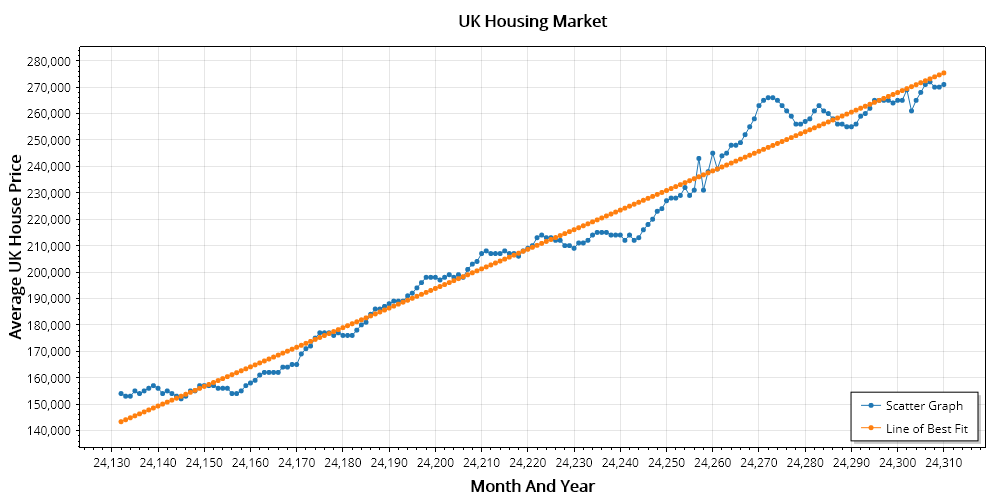

In [25]:
// Line of Best Fit Graph (using Utility Functions defined in Previous Code Cell).
using ScottPlot;
const int LINE_OF_BEST_FIT_EPOCHS = 2000; // You Can Adjust this Value to show the line of best fit at various numbers of epochs.
const double LINE_OF_BEST_FIT_ALPHA = 1; // Adjust Value of Learning Rate To See How Line of Best Fit Changes Depending On Learning Rate.
const string GRAPH_TITLE = "UK Housing Market"; // You Can Change the Title of the Displayed Graph to Anything You Like.
bool PLOT_NORMALIZED = false; // Personally, I Prefer Visualising With Un-Normalized Data but you can do so With Normalized Data if you wish.

var plt = new ScottPlot.Plot();

if (NUMBER_OF_FEATURES != 1)
    throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression..."); 
else
{
    double[] features = ReformatFeatures(PLOT_NORMALIZED);
    double[] targets = ReformatTargets(PLOT_NORMALIZED);

    var dataScatter = GetBaseScatterGraph(plt, features, targets, PLOT_NORMALIZED);
    plt.Title(GRAPH_TITLE);

    // Line of Best Fit Area.
    
    // Calculating Parameters.
    double[] parameters = new double[2]; // Exactly 2 Parameters: The Gradient (m) & y-intercept (c) for Univariate Data Respectively.
    
    // Learning Process (on Normalized features only).
    parameters = Learn(normalizedFeatures, normalizedTargets, parameters, LINE_OF_BEST_FIT_ALPHA, LINE_OF_BEST_FIT_EPOCHS);
    // Line of Best Fit!
    var bestFitScatter = GetLineOfBestFit(plt, features, parameters, PLOT_NORMALIZED);

    // Adding Legends for Readibility + Aesthetics:
    dataScatter.LegendText = "Scatter Graph";
    bestFitScatter.LegendText = "Line of Best Fit";
}
// Showing the Graph Automatically.
plt

Here is the .gif maker that shows how the line of best fit evolves as the number of epochs (training iterations) increases.<br>
Try tuning the learning rate or number of epochs to experiment with how the learning process changes!<br>
Note that the gif files are saved inside the same local directory as the one that contains this notebook.<br>

In [26]:
// Line of Best Fit Animated Gif.
using ImageMagick; // Helps Creates Gifs from a Series of Graphs.
using Microsoft.DotNet.Interactive; 

const int MAX_EPOCHS = 100; // Gif Would Show Line of Best fit from 1 to MAX_EPOCHS inclusive.
const double LEARNING_RATE = 1; // Adjust Value of Learning Rate To See How Line of Best Fit Evolves Depending on Learning Rate.
const int ANIMATION_DELAY = 10; // Animation Delay in Milliseconds (Controls How Smooth the Frames Are).
const int LINE_THICKNESS = 5; // Controls Thickness of the Line (mainly for aesthetics).
/*
Warning: Ensure the MAX_EPOCHS is no higher than 200 otherwise it would take an obscene amount of time to create the gif.
Experimentally, I found MAX_EPOCHS = 100 yields the most time-effective result.
*/
const string GRAPH_TITLE = "UK Housing Market"; // You Can Change the Title of the Displayed Graph to Anything You Like.
const string GIF_FILE_PATH = "housing market demo.gif"; // Exported GIF file Directory.

bool PLOT_NORMALIZED = false; // Personally, I Prefer Visualising With Un-Normalized Data but you can do so With Normalized Data if you wish.

var plt = new ScottPlot.Plot();

if (NUMBER_OF_FEATURES != 1)
    throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression..."); 
else
{
    double[] features = ReformatFeatures(PLOT_NORMALIZED);
    double[] targets = ReformatTargets(PLOT_NORMALIZED);

    var dataScatter = GetBaseScatterGraph(plt, features, targets, PLOT_NORMALIZED);
    dataScatter.LegendText = "Scatter Graph";
    plt.Title(GRAPH_TITLE);

    using (var collection = new MagickImageCollection())
    {
        // Credit to https://scottplot.net/faq/gif/ for most of the code in this section.
        double[] parameters = new double[2]; // Array of Parameters.

        // Initialisation of Previous Variables.
        ScottPlot.Plottables.Scatter prevLine = GetLineOfBestFit(plt, features, parameters, PLOT_NORMALIZED);
        prevLine.MarkerShape = MarkerShape.None; // Removes Any Points but Keeps the Line.
        prevLine.LineColor = ScottPlot.Colors.Orange; prevLine.MarkerColor = ScottPlot.Colors.Orange;
        prevLine.LineWidth = LINE_THICKNESS;
        var prevText = plt.Add.Annotation("Epoch #1"); // Text to Label Each Frame.

         Console.WriteLine($"Creating Epoch Frames...");
        for (int epoch = 1; epoch <= MAX_EPOCHS; epoch++)
        {
            // Updating Parameters.
            parameters = Learn(normalizedFeatures, normalizedTargets, parameters, LEARNING_RATE, 1); // One Iteration At A Time.
            // Creating Each Frame (One Extra Epoch = One Frame).
            var lineOfBestFit = GetLineOfBestFit(plt, features, parameters, PLOT_NORMALIZED); // Plots the Line of Best Fit Already.
            lineOfBestFit.LegendText = "Line of Best Fit";
            lineOfBestFit.MarkerShape = MarkerShape.None;
            lineOfBestFit.LineColor = ScottPlot.Colors.Orange; lineOfBestFit.MarkerColor = ScottPlot.Colors.Orange;
            lineOfBestFit.LineWidth = LINE_THICKNESS;
            // Adding Text:
            var text = plt.Add.Annotation($"Epoch #{epoch}");
            
            // Previous Line of Best Fit (& Text Object) Must Be Removed Before We Capture the Image.
            plt.Remove(prevLine);
            plt.Remove(prevText);
            
            prevLine = lineOfBestFit; // Re-Assigning the Current Line to the Previous Line.
            prevText = text; // Re-Assigning the Current Text to the Previous Text.
            
            // Creating an Image.
            byte[] bytes = plt.GetImageBytes(IMAGE_WIDTH, IMAGE_HEIGHT);
            MagickImage image = new(bytes) { AnimationDelay = ANIMATION_DELAY };
            collection.Add(image);
        }

        Console.WriteLine("Optimising gif...");
        collection.Optimize(); // Makes .gif run smoother.

        Console.WriteLine($"Saving gif as '{GIF_FILE_PATH}'...");
        // Saves the gif.
        using var outputStream = new MemoryStream();
        collection.Write(outputStream, MagickFormat.Gif);
        byte[] gifBytes = outputStream.ToArray();
        File.WriteAllBytes(GIF_FILE_PATH, gifBytes);
    } 
}
Console.WriteLine("gif creation complete!");
Console.WriteLine($"gif available at '{GIF_FILE_PATH}' in your local directory.");

Creating Epoch Frames...
Optimising gif...
Saving gif as 'housing market demo.gif'...
gif creation complete!
gif available at 'housing market demo.gif' in your local directory.



warning CS1701: Assuming assembly reference 'System.Memory, Version=8.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' used by 'Magick.NET-Q16-AnyCPU' matches identity 'System.Memory, Version=10.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' of 'System.Memory', you may need to supply runtime policy

warning CS1701: Assuming assembly reference 'System.Memory, Version=8.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' used by 'Magick.NET-Q16-AnyCPU' matches identity 'System.Memory, Version=10.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' of 'System.Memory', you may need to supply runtime policy



<h3>3.3 Gradient Descent Heatmap (Univariate Linear Regression Only)</h3>
<p>Finally, we will conclude this plotting section by showcasing the heart of the gradient descent algorithm. Gradient Descent Algorithm (at its core) is just a fancy way of sliding down the error function until you (hopefully) reach the bottom. This graph aims to show this, not by physically drawing out the error function as a 3D surface but as a heatmap.</p>
<p>A heatmap is commonly used in Machine Learning to show how high the error function is at certain points. In this case, the <b style = "color: red;">red</b> regions are where the error function is at its highest. Whereas, the <b style = "color: blue;">blue</b> regions are where the error function is at its lowest. This means that a point is steeper when there is a greater change in colour across the point (e.g. nearly instantly goes from red to green/blue).</p>
<p>For emphasis, my heatmap doesn't plot the Mean Squared Error directly: because the Mean Squared Error of a normalized dataset is quite small, I decide to use the <i>Natural Logarithm</i> of the MSE instead because it exaggerates the slight differences in errors, reflecting the real-world performance of certain parameters.</p>

Optimum Parameters: [1.1002513966480423, -0.07214618249534328]



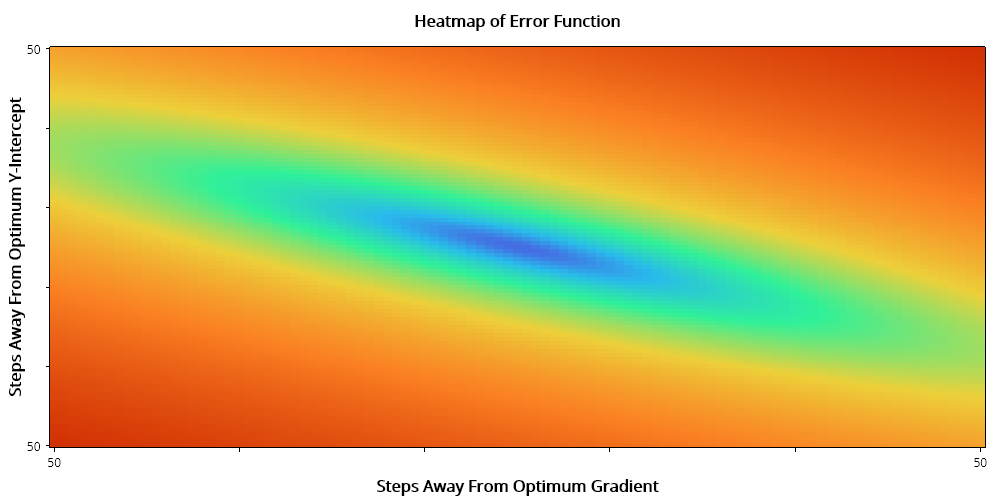

In [27]:
// Plotting the Heatmap
ScottPlot.Plot plt = new();
const double STEP_SIZE = 0.02; // Changes How Zoomed-in the Image Is.
const int MAX_STEPS = 50; // Maximum Number of Steps Away From Gradient & y-Intercept.
const int MAJOR_LABEL_SPACING = 100; // Number of Steps per large Division (think about like number of divisions per 1cm in a ruler!).
// Please Ensuring the MAJOR_LABEL_SPACING is a multiple of 5, otherwise the labels may appear glitchy.

// Creating HeatMap Array.
Console.WriteLine($"Optimum Parameters: {DisplayString<double>(parameters)}");
Coordinates3d[,] heatMap = new Coordinates3d[2*MAX_STEPS + 1, 2*MAX_STEPS + 1];

// Initialising Parameters to Change.
double m = parameters[0] - MAX_STEPS * STEP_SIZE;
double c = parameters[1] - MAX_STEPS * STEP_SIZE;

// Preparing Features & Targets (To Calculate MSE with).
double[] features = ReformatFeatures(true);
double[] targets = ReformatTargets(true);
if (NUMBER_OF_FEATURES != 1) throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression..."); 

// Creating arrays that store labels & their corresponding positions to both axes of the heatmap.
int minorLabelSpacing = MAJOR_LABEL_SPACING / 5;
string[] xLabels = new string[(2 * MAX_STEPS) / minorLabelSpacing  + 1]; // Steps Away from Optimum Gradient
string[] yLabels = new string[xLabels.Length]; // Steps Away from Optimum Intercept.

double[] xPositions = new double[xLabels.Length];
double[] yPositions = new double[xLabels.Length];

for (int num = 0; num <= 2 * MAX_STEPS; num += minorLabelSpacing)
{
    xPositions[num / minorLabelSpacing] = num;
    yPositions[num / minorLabelSpacing] = num;
    
    // Configuring Labels.
    xLabels[num / minorLabelSpacing] = "";
    yLabels[num / minorLabelSpacing] = "";
    if (num % MAJOR_LABEL_SPACING == 0)
    {
        // The Label Will Aim to Show Number of Steps Away from Optimum Position.
        // So Label Should Be "0" when num = MAX_STEPS for example.
        int label = num - MAX_STEPS;
        if (label < 0) label = -label; // Keep Label Positive.
        xLabels[num / minorLabelSpacing] = label.ToString();
        yLabels[num / minorLabelSpacing] = label.ToString();
    }
}

// Creating Heatmap.
for (int y = 0; y <= 2 * MAX_STEPS; y++)
{
    m = parameters[0] - MAX_STEPS * STEP_SIZE; // Gradient.
    for (int x = 0; x <= 2 * MAX_STEPS; x++)
    {
        // Calculating MSE.
        double[] predictions = new double[NUMBER_OF_ROWS];
        for (int i = 0; i < NUMBER_OF_ROWS; i++)
        {
            predictions[i] = m * features[i] + c;
        }
        // Adding Logarithm of Error Information on Our Heatmap.
        heatMap[y, x] = new (m, c, Math.Log(MeanSquaredError(predictions, targets)));
        m += STEP_SIZE;
    }
    
    c += STEP_SIZE; // Intercept.
}

// Plotting Heatmap.
var heatmap = plt.Add.Heatmap(heatMap);
heatmap.FlipVertically = true;
heatmap.Colormap = new ScottPlot.Colormaps.MellowRainbow(); // Choosing Colour Scheme Stated in Note Above.

// Adjusting x-axis labels.
plt.Axes.Bottom.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: xPositions,
    labels: xLabels
);
plt.Axes.Bottom.Label.Text = "Steps Away From Optimum Gradient";

// Adjusting y-axis labels.
plt.Axes.Left.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: yPositions,
    labels: yLabels
);
plt.Axes.Left.Label.Text = "Steps Away From Optimum Y-Intercept";

plt.Title("Heatmap of Error Function");
plt.Axes.TightMargins();
plt.HideGrid();

// Displaying Plot.
plt

<p>Here, we can also add extra information to our heatmap: we can also add the parameter points that show how the Gradient Descent Algorithm moves the point closer to the optimum centre (lowest point of error function) in the image.</p>


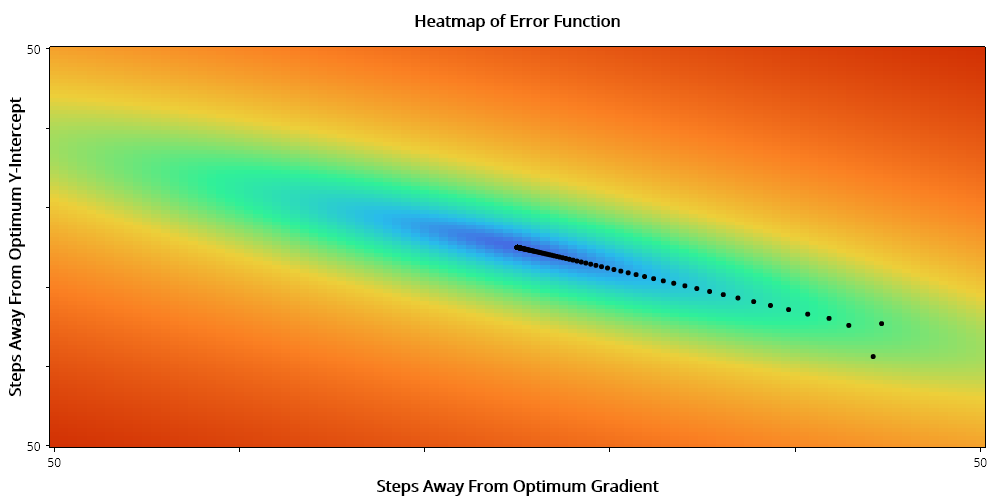

In [28]:
// Same Heat-Map Diagram as Previously, Except We Plot Points On the Image.
if (NUMBER_OF_FEATURES != 1) throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression...");
var plt = new ScottPlot.Plot();

// Re-drawing Heatmap (Equivalent to Re-setting Canvas EveryTime)
var heatmap = plt.Add.Heatmap(heatMap);
heatmap.FlipVertically = true;
heatmap.Colormap = new ScottPlot.Colormaps.MellowRainbow(); // Choosing Colour Scheme Stated in Note Above.

// Adjusting x-axis labels.
plt.Axes.Bottom.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: xPositions,
    labels: xLabels
);
plt.Axes.Bottom.Label.Text = "Steps Away From Optimum Gradient";

// Adjusting y-axis labels.
plt.Axes.Left.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: yPositions,
    labels: yLabels
);
plt.Axes.Left.Label.Text = "Steps Away From Optimum Y-Intercept";

plt.Title("Heatmap of Error Function");
plt.Axes.TightMargins();
plt.HideGrid();

// Plotting Scatter Points on Image Code Section
const int EPOCHS = 2000;
const double LEARNING_RATE = 1;

double[] errorParameters = new double[2]; // Purposes of Plotting Points on HeatMap Diagram Only.
if (NUMBER_OF_FEATURES != 1) throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression...");

// We Will Add Points on Our Heatmap.
for (int epoch = 1; epoch < EPOCHS; epoch++)
{
    // Training Our Model.
    errorParameters = Learn(normalizedFeatures, normalizedTargets, errorParameters, LEARNING_RATE, 1); // One Iteration At A Time.
    
    // Converting Parameters Back into Step-Size Labels.
    // Essentially involves rearranging the equation: m_0 = parameters[0] - x * STEP_SIZE where x is the STEP count.
    // Note that MAX_STEPS needs to be added to all of these so that when m_0 = parameters[0], x = MAX_STEPS
    double gradientStep = (parameters[0] - errorParameters[0]) / STEP_SIZE + MAX_STEPS;
    double interceptStep = (parameters[1] - errorParameters[1]) / STEP_SIZE + MAX_STEPS;

    // Plotting Scatter Graph On-top of Heatmap.
    var scatter = plt.Add.Scatter(gradientStep, interceptStep, color: Colors.Black);
    scatter.MarkerSize = 5;  
}

// Displaying Plot.
plt

<p>Here is another .gif version of the above code cell, which is helpful in identifying which point comes next on the heatmap.</p>

In [29]:
// Creating a Gif Of Points Being Added to the Heatmap.
using ImageMagick; // Helps Creates Gifs from a Series of Graphs.
using Microsoft.DotNet.Interactive; 

if (NUMBER_OF_FEATURES != 1) throw new Exception("Sorry! This Graph is Only Supported On Univariate Linear Regression...");

const int MAX_EPOCHS = 50; // Gif Would Show Line of Best fit from 1 to MAX_EPOCHS inclusive.
const double LEARNING_RATE = 1; // Adjust Value of Learning Rate To See How Line of Best Fit Evolves Depending on Learning Rate.
const int ANIMATION_DELAY = 50; // Animation Delay in Milliseconds (Controls How Smooth the Frames Are).
/*
Warning: Ensure the MAX_EPOCHS is no higher than 200 otherwise it would take an obscene amount of time to create the gif.
Experimentally, I found MAX_EPOCHS = 100 yields the most time-effective result.
*/
const string GRAPH_TITLE = "UK Housing Market Heatmap"; // You Can Change the Title of the Displayed Graph to Anything You Like.
const string GIF_FILE_PATH = "housing market heatmap demo.gif"; // Exported GIF file Directory.

var plt = new ScottPlot.Plot();

// Re-drawing Heatmap (Equivalent to Re-setting Canvas EveryTime)
var heatmap = plt.Add.Heatmap(heatMap);
heatmap.FlipVertically = true;
heatmap.Colormap = new ScottPlot.Colormaps.MellowRainbow(); // Choosing Colour Scheme Stated in Note Above.

// Adjusting x-axis labels.
plt.Axes.Bottom.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: xPositions,
    labels: xLabels
);
plt.Axes.Bottom.Label.Text = "Steps Away From Optimum Gradient";

// Adjusting y-axis labels.
plt.Axes.Left.TickGenerator = new ScottPlot.TickGenerators.NumericManual(
    positions: yPositions,
    labels: yLabels
);
plt.Axes.Left.Label.Text = "Steps Away From Optimum Y-Intercept";

plt.Title(GRAPH_TITLE);
plt.Axes.TightMargins();
plt.HideGrid();

// Gif Generation Starts Here.
using (var collection = new MagickImageCollection())
{
    double[] errorParameters = new double[2]; // Array of Parameters.

     Console.WriteLine($"Creating Epoch Frames...");
    for (int epoch = 1; epoch <= MAX_EPOCHS; epoch++)
    {
        // Updating Parameters.
        errorParameters = Learn(normalizedFeatures, normalizedTargets, errorParameters, LEARNING_RATE, 1); // One Iteration At A Time.
    
        // Converting Parameters Back into Step-Size Labels.
        // Essentially involves rearranging the equation: m_0 = parameters[0] - x * STEP_SIZE where x is the STEP count.
        // Note that MAX_STEPS needs to be added to all of these so that when m_0 = parameters[0], x = MAX_STEPS
        double gradientStep = (parameters[0] - errorParameters[0]) / STEP_SIZE + MAX_STEPS;
        double interceptStep = (parameters[1] - errorParameters[1]) / STEP_SIZE + MAX_STEPS;

        // Plotting Scatter Graph On-top of Heatmap.
        var scatter = plt.Add.Scatter(gradientStep, interceptStep, color: Colors.Black);
        scatter.MarkerSize = 5;  
        
        // Creating an Image.
        byte[] bytes = plt.GetImageBytes(IMAGE_WIDTH, IMAGE_HEIGHT);
        MagickImage image = new(bytes) { AnimationDelay = ANIMATION_DELAY };
        collection.Add(image);
    }

    Console.WriteLine("Optimising gif...");
    collection.Optimize(); // Makes .gif run smoother.

    Console.WriteLine($"Saving gif as '{GIF_FILE_PATH}'...");
    // Saves the gif.
    using var outputStream = new MemoryStream();
    collection.Write(outputStream, MagickFormat.Gif);
    byte[] gifBytes = outputStream.ToArray();
    File.WriteAllBytes(GIF_FILE_PATH, gifBytes);
} 
Console.WriteLine("gif creation complete!");
Console.WriteLine($"gif available at '{GIF_FILE_PATH}' in your local directory.");

Creating Epoch Frames...
Optimising gif...
Saving gif as 'housing market heatmap demo.gif'...
gif creation complete!
gif available at 'housing market heatmap demo.gif' in your local directory.



warning CS1701: Assuming assembly reference 'System.Memory, Version=8.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' used by 'Magick.NET-Q16-AnyCPU' matches identity 'System.Memory, Version=10.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' of 'System.Memory', you may need to supply runtime policy

warning CS1701: Assuming assembly reference 'System.Memory, Version=8.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' used by 'Magick.NET-Q16-AnyCPU' matches identity 'System.Memory, Version=10.0.0.0, Culture=neutral, PublicKeyToken=cc7b13ffcd2ddd51' of 'System.Memory', you may need to supply runtime policy



<div id = "dataset" /><h2>4. Other Datasets</h2>
<p>Here (in this section), I will provide extra details on what other datasets I already have in the same directory as this notebook for you to use. I will also include the details of the "Advertising Sales" dataset. From there, you can take a look inside the datasets (and especially the headers) to gain an understanding of the datasets I provide. Above all, I will also provide Transformers and Inverse Transformers that are required for each dataset in order to convert all the values into a usable format.</p>

<h3>4.1 Advertising Sales Dataset</h3>
This dataset is ideal for multivariate linear regression, because it contains decently strong linear relationships and it takes in a total of 3 input features. This is why I used it extensively as an example for Section 2 of this notebook.
Here is all the code you should copy into the other cells in this notebook. Then if you run all the cells in Sections 1 and 2, it should work on its own.

In [ ]:
// Section 1
const string TRAINING_DATA_PATH = @"Datasets\advertising\advertising.csv"; 
const string HEADER_PATH = @"Datasets\advertising\header.txt"; 
const string SEPARATOR = ",";
const int TARGET_LOCATION = 3;

// Section 1.1
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        transformedFeatures[i] = double.Parse(featuresToTransform[i]);
    }
    return transformedFeatures;
}

double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    double transformedTarget = double.Parse(targetToTransform);
    return transformedTarget;
}

// Section 2.5
string InverseTransform(double transformedTarget)
{
    return transformedTarget.ToString();
}

// Recommended to use 20,000 and Learning Rate = 1

<h3>4.2 UK House Price By Date Dataset (Normal)</h3>
<p>This dataset is ideal for modelling the strengths of univariate linear regression because this dataset focuses on house prices over a relatively <b>recent</b> timeline (back until 2011), which is a more linear trend. In contrast, its sister dataset (4.3 below) is a demonstration of the weaknesses of just considering recent trends. Anyway, I actively used this dataset when I was testing out my graphs, so you should get quite good results by using the dataset.</p>

In [31]:
// Section 1
const string TRAINING_DATA_PATH = @"Datasets\house prices\train.data"; 
const string HEADER_PATH = @"Datasets\house prices\date headers (tabs).txt"; 
const string SEPARATOR = "\t";
const int TARGET_LOCATION = 1;

// Section 1.1
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        // You Can Add Code Here to Modify the Transformer to suit your dataset.
        string featureToTransform = featuresToTransform[i];
        string[] monthAndYear = featureToTransform.Split(" ");
        string month = monthAndYear[0]; int year = int.Parse(monthAndYear[1]);
        int monthNumber;
        switch (month)
        {
            case "Jan":
                monthNumber = 0; break;
            case "Feb":
                monthNumber = 1; break;
            case "Mar":
                monthNumber = 2; break;
            case "Apr":
                monthNumber = 3; break;
            case "May":
                monthNumber = 4; break;
            case "Jun":
                monthNumber = 5; break;
            case "June":
                monthNumber = 5; break;
            case "Jul":
                monthNumber = 6; break;
            case "July":
                monthNumber = 6; break;
            case "Aug":
                monthNumber = 7; break;
            case "Sep":
                monthNumber = 8; break;
            case "Oct":
                monthNumber = 9; break;
            case "Nov":
                monthNumber = 10; break;
            case "Dec":
                monthNumber = 11; break;
            default:
                throw new Exception("Invalid Month Name!");
        }
        // Multiplying Year By 12 and Adding On Month Number is Easiest Way to Create 1-1 correspondence between dates and numbers.
        transformedFeatures[i] = 12 * year + monthNumber;
    }
    return transformedFeatures;
}

double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    double transformedTarget = double.Parse(targetToTransform);
    return transformedTarget;
}

// Section 2.5
string InverseTransform(double transformedTarget)
{
    return transformedTarget.ToString();
}

// Recommended to use 20,000 and Learning Rate = 1

<h3>4.3 UK House Price By Date Dataset (Extended)</h3>
<p>This dataset is one of the few datasets that demonstrates the limitations of using a naive linear regression model on a relationship very much known to be non-linear. This time, the house data has been extended as far back as the 1950s. If you want to see awful results (which itself is very interesting) and want to see why linear regression on its own isn't used very much, then this is the dataset for you!</p>

In [32]:
// Section 1
const string TRAINING_DATA_PATH = @"Datasets\house prices\extended.data"; 
const string HEADER_PATH = @"Datasets\house prices\date headers (spaces).txt"; 
const string SEPARATOR = "    ";
const int TARGET_LOCATION = 1;

// Section 1.1
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        // You Can Add Code Here to Modify the Transformer to suit your dataset.
        string featureToTransform = featuresToTransform[i];
        string[] monthAndYear = featureToTransform.Split(" ");
        string month = monthAndYear[0]; int year = int.Parse(monthAndYear[1]);
        int monthNumber;
        switch (month)
        {
            case "Jan":
                monthNumber = 0; break;
            case "Feb":
                monthNumber = 1; break;
            case "Mar":
                monthNumber = 2; break;
            case "Apr":
                monthNumber = 3; break;
            case "May":
                monthNumber = 4; break;
            case "Jun":
                monthNumber = 5; break;
            case "June":
                monthNumber = 5; break;
            case "Jul":
                monthNumber = 6; break;
            case "July":
                monthNumber = 6; break;
            case "Aug":
                monthNumber = 7; break;
            case "Sep":
                monthNumber = 8; break;
            case "Oct":
                monthNumber = 9; break;
            case "Nov":
                monthNumber = 10; break;
            case "Dec":
                monthNumber = 11; break;
            default:
                throw new Exception("Invalid Month Name!");
        }
        // Multiplying Year By 12 and Adding On Month Number is Easiest Way to Create 1-1 correspondence between dates and numbers.
        transformedFeatures[i] = 12 * year + monthNumber;
    }
    return transformedFeatures;
}

double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    double transformedTarget = double.Parse(targetToTransform);
    return transformedTarget;
}

// Section 2.5
string InverseTransform(double transformedTarget)
{
    return transformedTarget.ToString();
}

// Recommended to use 20,000 and Learning Rate = 1

<h3>4.4 California Housing Dataset</h3>
An even more complex, multivariate version of the 4.2 and 4.3 Housing Datasets, likely to make my model scream in pain (no literally: you may see performance issues because of the number of features and rows to analyse)! If you want to see diabolical results that would make you question why I made this model in the first place and if you would like to see a fundamental limitation in ML technologies (namely limited computing power), then use this dataset!

In [33]:
// Section 1
const string TRAINING_DATA_PATH = @"Datasets\house prices\california.csv"; 
const string HEADER_PATH = @"Datasets\house prices\california headers.txt"; 
const string SEPARATOR = ",";
const int TARGET_LOCATION = 6; // Goal: Predict Median House Value of Certain Districts.

// Section 1.1
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        
        transformedFeatures[i] = double.Parse(featuresToTransform[i]); // At Least Extracting the Data is Relatively Simple!
    }
    return transformedFeatures;
}

double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    double transformedTarget = double.Parse(targetToTransform);
    return transformedTarget;
}

// Section 2.5
string InverseTransform(double transformedTarget)
{
    return transformedTarget.ToString();
}

// Recommended to use 1,000 epochs & learning rate = 0.1

<h3>4.5 Students Dataset</h3>
<p>You are given 36 features and 1 target value, with the goal of predicting whether a student is a dropout, graduate or enrolled. While this is technically a classification task, linear regression can also work here by using a special InverseTransform function that converts the predicted values back into class categories. In a neural network, the Inverse Transform function actually acts as a Activation Function (e.g. SoftMax) that transforms a single value into an set of probabilities that indicate how likely each category fits the data given to the model. Like Dataset 4.4, there may be performance issues and due to the vast amounts of non-linear relationships, the model may very much struggle with this dataset.</p>

In [34]:
// Section 1
const string TRAINING_DATA_PATH = @"Datasets\students\train.data"; // Can Also use @"Datasets\students\test.data", but it doesn't matter...
const string HEADER_PATH = @"Datasets\students\headers.txt"; 
const string SEPARATOR = ";";
const int TARGET_LOCATION = 36; // (yes! There are a total of 36 features where the last one is the target to predict).

// Section 1.1
double[] FeatureTransformer(string[] featuresToTransform) 
{
    // Transformer Function that Takes in A Series of Features (read from left-to-right in each line) & Transforms them!
    double[] transformedFeatures = new double[featuresToTransform.Length];
    for (int i = 0; i < featuresToTransform.Length; i++)
    {
        
        transformedFeatures[i] = double.Parse(featuresToTransform[i]); // At Least Extracting the Data is Relatively Simple!
    }
    return transformedFeatures;
}

double TargetTransformer(string targetToTransform) 
{
    // Transformer Function that Takes in A Target & Transforms them!
    switch (targetToTransform.ToLower())
    {
        case "dropout":
            return 0;
        case "graduate":
            return 1;
        case "enrolled":
            return 2;
        default:
            throw new Exception($"Unexpected Value: {targetToTransform}");
    }
}

// Section 2.5
string InverseTransform(double transformedTarget)
{
    int compareValue = (int)Math.Round(transformedTarget);
    switch (compareValue)
    {
        case 0:
            return "Dropout";
        case 1:
            return "Graduate";
        case 2:
            return "Enrolled";
        default:
            return "I've got no clue...";
    }
}

// Recommended to use 1,000 epochs & learning rate = 0.1

<h3>4.6 Your Own Dataset</h3>
<p>Of course! I encourage you to find your own datasets and try out my linear regression model on them. If you want a challenge, you can even try improving my linear regression model to make it more efficient on datasets with lots of features.</p>

<h2>5. Conclusion</h2>
<p>Congrats for making it through the notebook! Hope this got you more excited about AI (that's because it did for me!).</p>
<p>If you experience any issues with this document, then please let me know via my email: saksham.rs@gmail.com</p>
<p>Thanks a lot!</p>